# Part 3: PCA Meets CNNs — Analyzing and Initializing Deep Representations


## Part 0: Environment Setup & Imports

In [ ]:
# Core imports (provided - do not modify)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision
import torchvision.transforms as transforms

# Analysis and visualization
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm
import time
import copy

# Set seeds for reproducibility (DO NOT MODIFY)
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla P100-PCIE-16GB


In [ ]:
# Configuration (provided - do not modify)
CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Hyperparameters (fixed for fair comparison - DO NOT MODIFY)
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
NUM_EPOCHS = 10
NUM_CLASSES = 10

## Part 1: Data Loading & Exploration

In [ ]:
# Data loading (provided - do not modify)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # Fashion-MNIST statistics
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


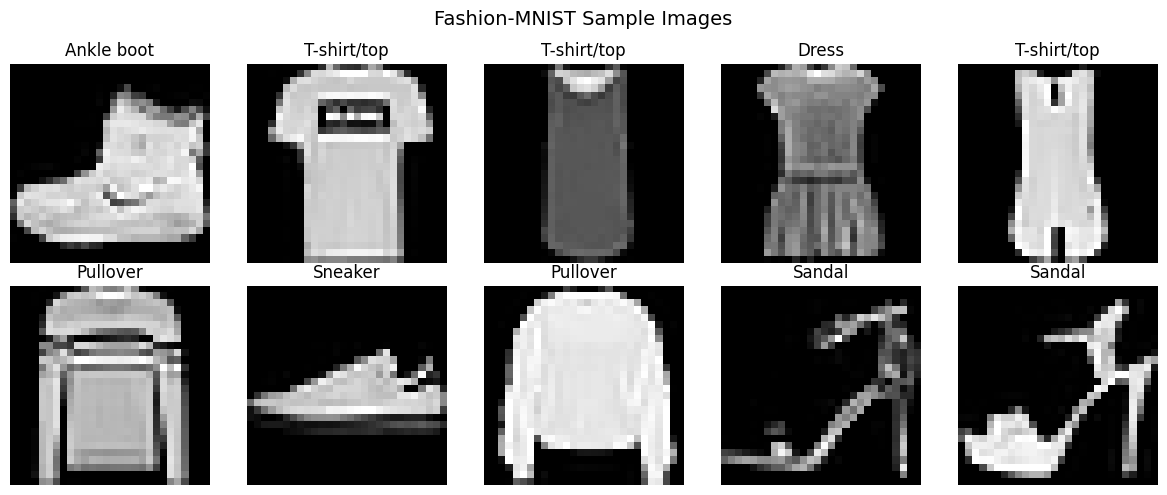

In [ ]:
# Visualize sample images (provided - do not modify)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(CLASS_NAMES[label])
    ax.axis('off')
plt.suptitle('Fashion-MNIST Sample Images', fontsize=14)
plt.tight_layout()
plt.show()

## Part 2: CNN Architecture with Feature Extraction Hooks

Build a CNN with **forward hooks** to capture intermediate layer activations. This allows us to analyze what the network learns at each stage.

**Architecture Specification:**
```
Conv1 (1->32, kernel=3, padding=1) -> ReLU -> MaxPool(2)
Conv2 (32->64, kernel=3, padding=1) -> ReLU -> MaxPool(2)
Conv3 (64->128, kernel=3, padding=1) -> ReLU -> MaxPool(2)
Flatten -> FC1 (128*3*3 -> 256) -> ReLU -> FC2 (256 -> 10)
```

In [ ]:
class CNN(nn.Module):
    """
    A simple CNN for Fashion-MNIST classification.
    Architecture:
        Conv1 (1->32) -> ReLU -> MaxPool
        Conv2 (32->64) -> ReLU -> MaxPool
        Conv3 (64->128) -> ReLU -> MaxPool
        Flatten -> FC1 (128*3*3 -> 256) -> ReLU -> FC2 (256 -> 10)
    """

    def __init__(self, num_classes=10):
        super(CNN, self).__init__()

        # TODO: Define convolutional layers
        # self.conv1 = ...
        # self.conv2 = ...
        # self.conv3 = ...

        # TODO: Define pooling layer
        # self.pool = ...

        # TODO: Define fully connected layers
        # Hint: After 3 pooling operations: 28 -> 14 -> 7 -> 3
        # self.fc1 = ...
        # self.fc2 = ...
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, num_classes)

        # Storage for intermediate activations (provided)
        self.activations = {}

    def forward(self, x):
        # TODO: Implement forward pass
        # Hint: Use x.view(x.size(0), -1) to flatten
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

    def register_activation_hooks(self):
        """
        Register forward hooks to capture activations at each layer.
        Returns list of hook handles for later removal.
        """
        hooks = []

        def get_activation(name):
            def hook(module, input, output):
                self.activations[name] = output.detach()
            return hook

        # TODO: Register hooks for conv1, conv2, conv3, fc1
        # Example: hooks.append(self.conv1.register_forward_hook(get_activation('conv1')))
        hooks.append(self.conv1.register_forward_hook(get_activation('conv1')))
        hooks.append(self.conv2.register_forward_hook(get_activation('conv2')))
        hooks.append(self.conv3.register_forward_hook(get_activation('conv3')))
        hooks.append(self.fc1.register_forward_hook(get_activation('fc1')))

        return hooks

    def clear_activations(self):
        """Clear stored activations to free memory."""
        self.activations = {}

In [ ]:
# Verify model architecture (run after completing CNN class)
model = CNN(num_classes=NUM_CLASSES).to(device)
print(model)

# Test forward pass
dummy_input = torch.randn(2, 1, 28, 28).to(device)
dummy_output = model(dummy_input)

# Validation assertions
assert dummy_output.shape == (2, 10), f"Expected output shape (2, 10), got {dummy_output.shape}"
print(f"\n✓ Input shape: {dummy_input.shape}")
print(f"✓ Output shape: {dummy_output.shape}")
print("✓ Model architecture verified!")

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

✓ Input shape: torch.Size([2, 1, 28, 28])
✓ Output shape: torch.Size([2, 10])
✓ Model architecture verified!


## Part 3: Training Infrastructure 

Implement reusable training and evaluation functions.

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """
    Train for one epoch.

    Args:
        model: The CNN model
        train_loader: DataLoader for training data
        criterion: Loss function (CrossEntropyLoss)
        optimizer: Optimizer (Adam)
        device: cuda or cpu

    Returns:
        avg_loss: Average loss over all batches
        accuracy: Training accuracy (percentage)
    """
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # TODO: Implement training step
        # 1. Zero gradients
        # 2. Forward pass
        # 3. Compute loss
        # 4. Backward pass
        # 5. Update weights

        # TODO: Update running_loss, correct, total
        # Hint: Use outputs.max(1) to get predictions

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()


    return running_loss / len(train_loader), 100. * correct / total


def evaluate(model, test_loader, criterion, device):
    """
    Evaluate on test set.

    Args:
        model: The CNN model
        test_loader: DataLoader for test data
        criterion: Loss function
        device: cuda or cpu

    Returns:
        avg_loss: Average test loss
        accuracy: Test accuracy (percentage)
    """
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            # TODO: Implement evaluation step
            # 1. Forward pass
            # 2. Compute loss
            # 3. Update running_loss, correct, total
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return running_loss / len(test_loader), 100. * correct / total


In [ ]:
def train_model(model, train_loader, test_loader, num_epochs, learning_rate, device, verbose=True):
    """
    Full training loop with loss/accuracy tracking.
    Returns training history dictionary.

    (Provided - do not modify)
    """
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        'train_loss': [], 'train_acc': [],
        'test_loss': [], 'test_acc': [],
        'epoch_times': []
    }

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        test_loss, test_acc = evaluate(model, test_loader, criterion, device)

        epoch_time = time.time() - start_time

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        history['epoch_times'].append(epoch_time)

        if verbose:
            print(f"Epoch [{epoch+1}/{num_epochs}] "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
                  f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}% | "
                  f"Time: {epoch_time:.1f}s")

    return history

## Part 4: Train Baseline CNN (Gold Standard)

First, we train a baseline CNN with **random initialization** to establish our "Gold Standard" performance.

In [ ]:
# Train baseline model (provided - do not modify)
print("="*60)
print("Training Baseline CNN (Random Initialization)")
print("="*60)

baseline_model = CNN(num_classes=NUM_CLASSES).to(device)
baseline_start = time.time()
baseline_history = train_model(
    baseline_model, train_loader, test_loader,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE, device=device
)
baseline_total_time = time.time() - baseline_start

print(f"\nTotal training time: {baseline_total_time:.1f}s")
print(f"Final Test Accuracy: {baseline_history['test_acc'][-1]:.2f}%")

Training Baseline CNN (Random Initialization)
Epoch [1/10] Train Loss: 0.5156, Train Acc: 81.46% | Test Loss: 0.3543, Test Acc: 86.93% | Time: 8.7s
Epoch [2/10] Train Loss: 0.3052, Train Acc: 88.93% | Test Loss: 0.3818, Test Acc: 85.49% | Time: 8.7s
Epoch [3/10] Train Loss: 0.2570, Train Acc: 90.53% | Test Loss: 0.2625, Test Acc: 90.32% | Time: 8.4s
Epoch [4/10] Train Loss: 0.2289, Train Acc: 91.57% | Test Loss: 0.2656, Test Acc: 90.03% | Time: 8.5s
Epoch [5/10] Train Loss: 0.1999, Train Acc: 92.56% | Test Loss: 0.2462, Test Acc: 91.16% | Time: 8.5s
Epoch [6/10] Train Loss: 0.1820, Train Acc: 93.22% | Test Loss: 0.2301, Test Acc: 91.88% | Time: 8.4s
Epoch [7/10] Train Loss: 0.1627, Train Acc: 93.90% | Test Loss: 0.2322, Test Acc: 91.44% | Time: 8.5s
Epoch [8/10] Train Loss: 0.1460, Train Acc: 94.55% | Test Loss: 0.2314, Test Acc: 91.88% | Time: 8.5s
Epoch [9/10] Train Loss: 0.1283, Train Acc: 95.19% | Test Loss: 0.2476, Test Acc: 91.45% | Time: 8.5s
Epoch [10/10] Train Loss: 0.1112, Tr

## Part 5: PCA Analysis of CNN Latent Spaces 

Now we analyze **what the CNN has learned** by extracting activations from each layer and applying PCA to visualize the representation structure.

**Tasks:**
1. Implement `extract_activations()` to get layer outputs using hooks
2. Implement `visualize_pca_latent_space()` to create PCA visualizations

In [ ]:
def extract_activations(model, data_loader, device, num_samples=2000):
    """
    Extract activations from all hooked layers for a subset of data.

    Args:
        model: Trained CNN with activation hooks
        data_loader: DataLoader to extract activations from
        device: cuda or cpu
        num_samples: Maximum number of samples to process

    Returns:
        all_activations: dict of {layer_name: numpy array of shape (num_samples, features)}
        all_labels: numpy array of labels
    """
    model.eval()
    hooks = model.register_activation_hooks()

    all_activations = {name: [] for name in ['conv1', 'conv2', 'conv3', 'fc1']}
    all_labels = []
    samples_collected = 0

    with torch.no_grad():
        for images, labels in data_loader:
            if samples_collected >= num_samples:
                break

            # TODO: Move images to device and run forward pass
            # The forward pass will trigger the hooks and populate model.activations
            images = images.to(device)
            _ = model(images)


            for name in all_activations.keys():
                # TODO: Get activation from model.activations[name]
                # For conv layers (4D tensor), apply global average pooling
                # Hint: if len(act.shape) == 4: act = act.mean(dim=(2, 3))

                act = model.activations[name]
                if len(act.shape) == 4:
                    act = act.mean(dim=(2, 3))
                all_activations[name].append(act.cpu().numpy())
            all_labels.append(labels.numpy())
            samples_collected += images.size(0)

            model.clear_activations()

    # Remove hooks
    for hook in hooks:
        hook.remove()

    # TODO: Concatenate all batches and convert to numpy
    # Slice to exactly num_samples
    for name in all_activations:
        all_activations[name] = np.concatenate(all_activations[name], axis=0)[:num_samples]
    all_labels = np.concatenate(all_labels, axis=0)[:num_samples]

    return all_activations, all_labels

In [ ]:
# Extract activations from trained baseline model
print("Extracting activations from trained CNN...")
activations, labels = extract_activations(baseline_model, test_loader, device, num_samples=2000)

# Validation
print("\nActivation shapes per layer:")
for name, act in activations.items():
    print(f"  {name}: {act.shape}")
    assert len(act) == 2000, f"Expected 2000 samples, got {len(act)}"

print("\n✓ Activation extraction verified!")

Extracting activations from trained CNN...

Activation shapes per layer:
  conv1: (2000, 32)
  conv2: (2000, 64)
  conv3: (2000, 128)
  fc1: (2000, 256)

✓ Activation extraction verified!


In [ ]:
def visualize_pca_latent_space(activations, labels, layer_name, class_names):
    """
    Apply PCA to layer activations and create 2D visualization.

    Args:
        activations: numpy array of shape (num_samples, features)
        labels: numpy array of class labels
        layer_name: Name of the layer (for plot title)
        class_names: List of class names for legend

    Returns:
        pca: Fitted PCA object
        n_components_95: Number of components for 95% variance
    """
    # TODO: Step 1 - Standardize features using StandardScaler

    # TODO: Step 2 - Apply PCA with n_components = min(50, num_features)
    scaler = StandardScaler()
    activations_scaled = scaler.fit_transform(activations)

    n_components = min(50, activations.shape[1])
    pca = PCA(n_components=n_components)
    pca_result = pca.fit_transform(activations_scaled)

    # Create visualization (provided structure)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # TODO: Left plot - 2D scatter of PC1 vs PC2, colored by labels
    # Add labels and title with explained variance percentages

    # TODO: Right plot - Cumulative explained variance
    # Add 95% threshold line

    # TODO: Find number of components for 95% variance
    scatter = axes[0].scatter(pca_result[:, 0], pca_result[:, 1],
                             c=labels, cmap='tab10', alpha=0.6, s=10)
    axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    axes[0].set_title(f'{layer_name}: PCA Latent Space')
    cbar = plt.colorbar(scatter, ax=axes[0], ticks=range(10))
    cbar.set_label('Class')
    axes[0].grid(True, alpha=0.3)

    cumsum_var = np.cumsum(pca.explained_variance_ratio_)
    axes[1].plot(range(1, len(cumsum_var) + 1), cumsum_var * 100, 'b-', linewidth=2)
    axes[1].axhline(y=95, color='r', linestyle='--', linewidth=2, label='95% threshold')
    axes[1].set_xlabel('Number of Components')
    axes[1].set_ylabel('Cumulative Explained Variance (%)')
    axes[1].set_title(f'{layer_name}: Explained Variance')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    n_components_95 = np.argmax(cumsum_var >= 0.95) + 1
    axes[1].axvline(x=n_components_95, color='g', linestyle='--', linewidth=2,
                   label=f'{n_components_95} components')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return pca, n_components_95


Analyzing Layer: conv1


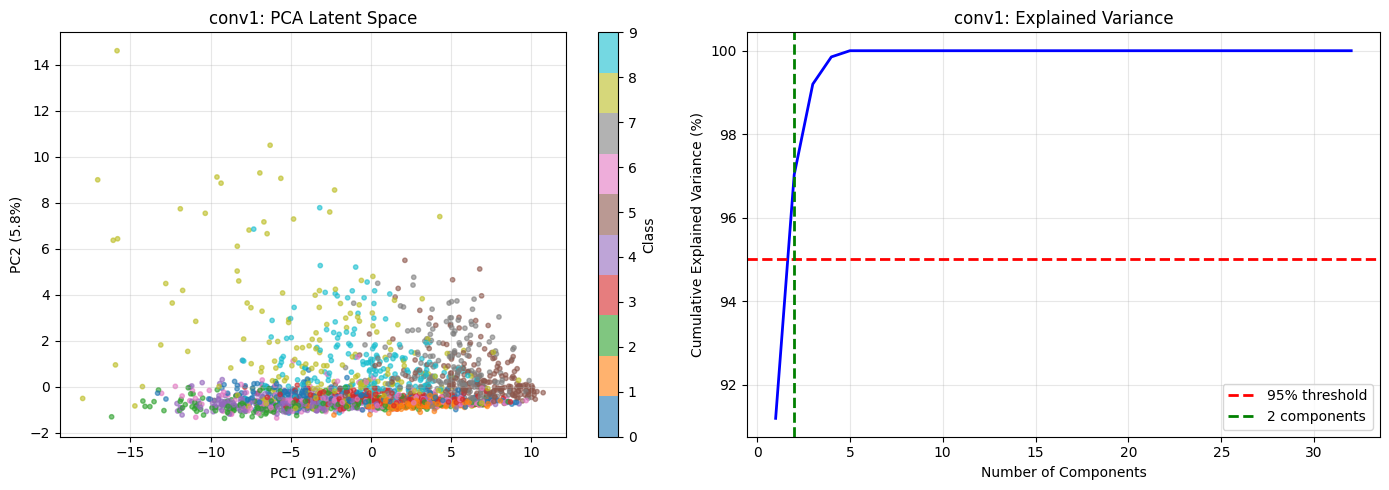

Components needed for 95% variance: 2

Analyzing Layer: conv2


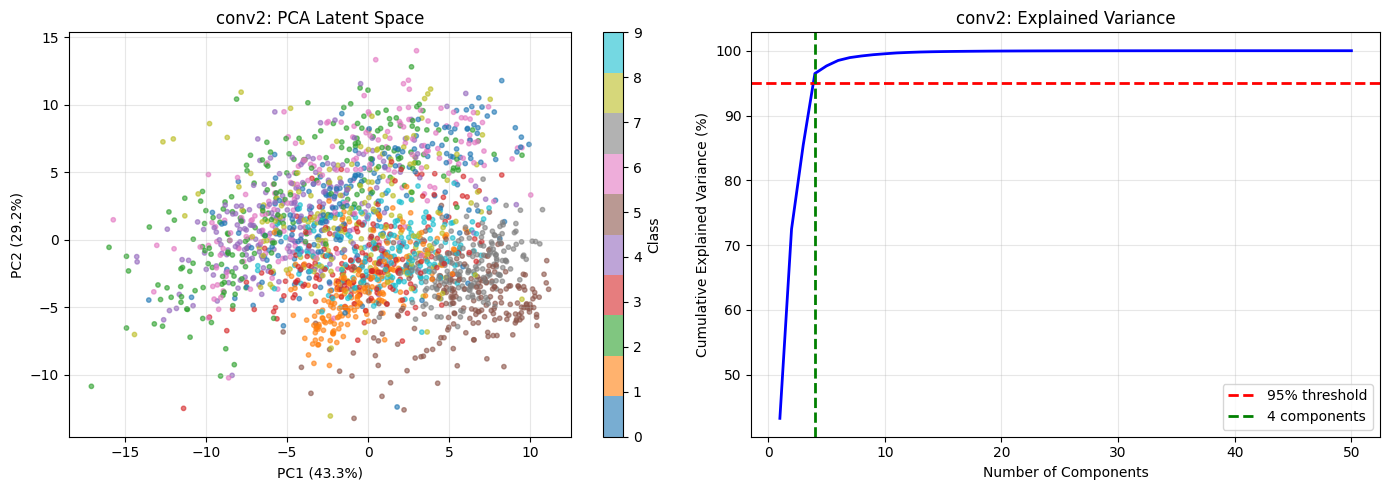

Components needed for 95% variance: 4

Analyzing Layer: conv3


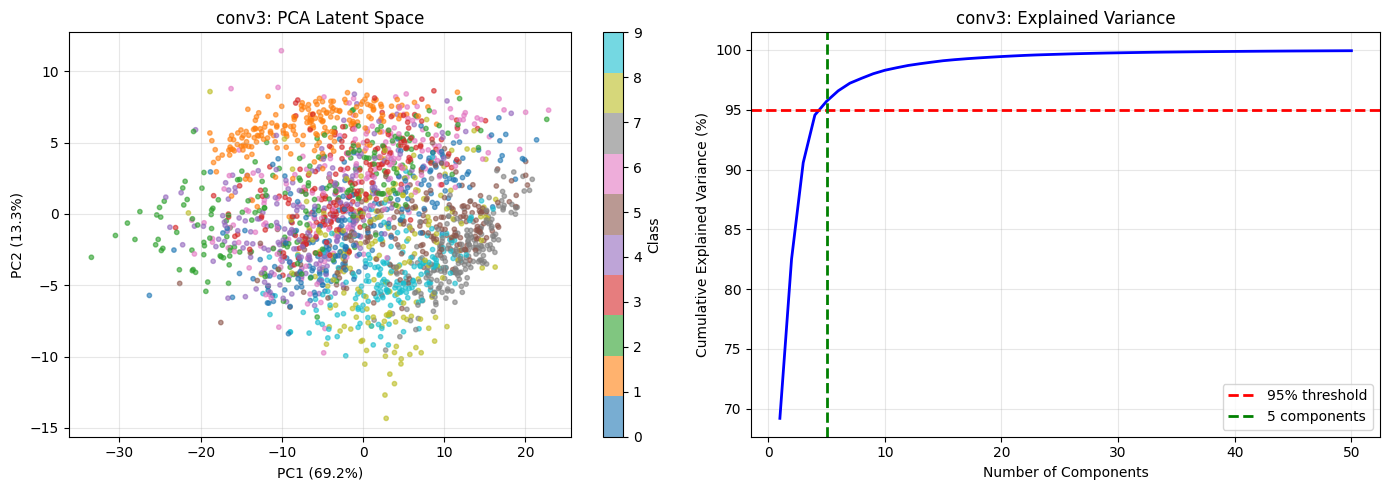

Components needed for 95% variance: 5

Analyzing Layer: fc1


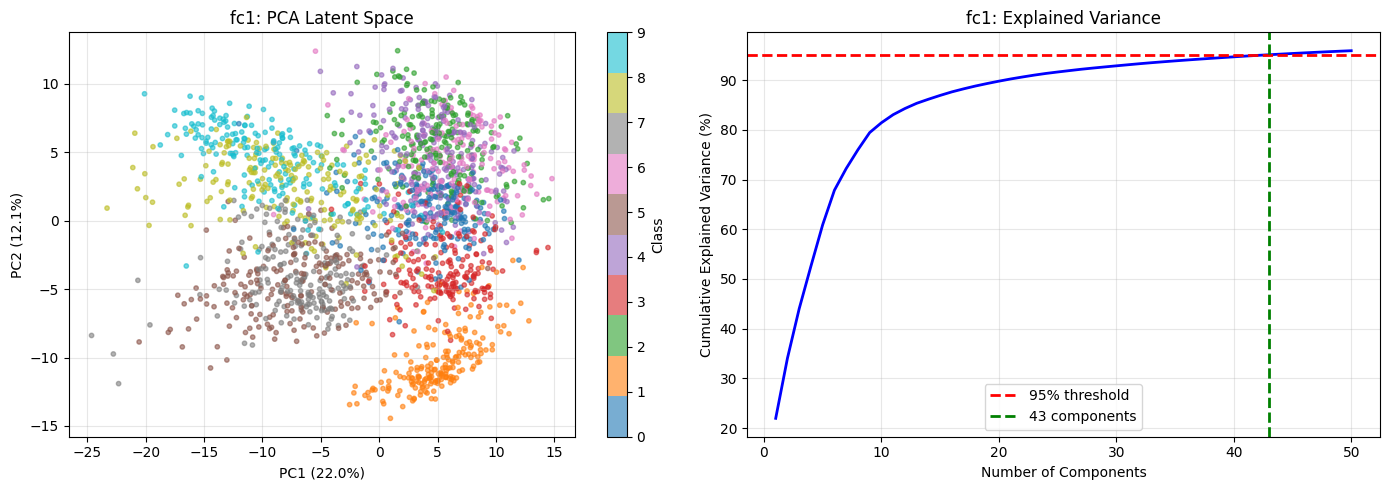

Components needed for 95% variance: 43


In [ ]:
# Visualize PCA for each layer
intrinsic_dims = {}

for layer_name in ['conv1', 'conv2', 'conv3', 'fc1']:
    print(f"\n{'='*50}")
    print(f"Analyzing Layer: {layer_name}")
    print(f"{'='*50}")

    pca, n_components = visualize_pca_latent_space(
        activations[layer_name], labels, layer_name, CLASS_NAMES
    )
    intrinsic_dims[layer_name] = n_components
    print(f"Components needed for 95% variance: {n_components}")


INTRINSIC DIMENSIONALITY SUMMARY


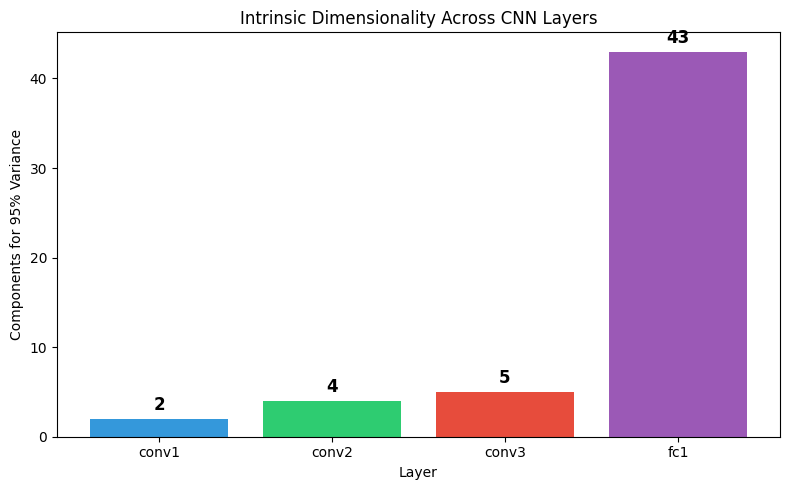

In [ ]:
# Summary: Intrinsic dimensionality across layers (provided)
print("\n" + "="*50)
print("INTRINSIC DIMENSIONALITY SUMMARY")
print("="*50)

layers = list(intrinsic_dims.keys())
dims = list(intrinsic_dims.values())

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(layers, dims, color=['#3498db', '#2ecc71', '#e74c3c', '#9b59b6'])
ax.set_xlabel('Layer')
ax.set_ylabel('Components for 95% Variance')
ax.set_title('Intrinsic Dimensionality Across CNN Layers')

# Add value labels on bars
for bar, dim in zip(bars, dims):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(dim), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### 📝 Analysis Question

Based on the intrinsic dimensionality analysis:

1. How does the intrinsic dimensionality change as we go deeper in the network?
2. What does this suggest about how the CNN processes information?
3. Which layer has the most class-separable representations (based on the PCA scatter plots)?

** Answer:** (Write 3-5 sentences)
The intrinsicdimensionality increasesthen sharply jumps at the fullyconnected layer: conv1 requires only 2 components for 95% variance,conv2 requires 4, conv3 requires 5, and fc1 requires 43. Thipattern reveals that earlyconvolutional layers produce highly redundan, low-dimensional representations, the 32or 64 channels are largely correlated because they detect similar low-level features like edgesand textures. As we go deeper, the network builds increasingly complex and diverse feature combinations, culminating in fc1 where 43 independent dimensions are needed to capture 95% of the variation.This suggests the CNN is progressively expanding its representationalcomplexity to separate classes, not compressing information until the very end.Based on the PCA scatter plots, fc1 has the most class-separable representations, as its 43-dimensional pace allowsthe network to spread the 10classes into distinct, well-separated clsters,whereas conv1 and conv2 scatter plots show heavy class overlapsince those layers have not yet built discriminative features.

*[Double-click to edit this cell and write your answer here]*




## Part 6: PCA-Initialized Convolutional Filters

Now we explore whether we can use **PCA eigenvectors** to initialize the first convolutional layer. The idea is that PCA captures the principal directions of variation in image patches, which might provide a better starting point than random initialization.

**Tasks:**
1. Implement `extract_patches()` to extract image patches
2. Implement `compute_pca_filters()` to compute PCA eigenvectors as filters
3. Implement `create_pca_initialized_model()` to initialize CNN with PCA filters

**Key Insight:**
- Our conv1 uses 3×3 kernels and needs 32 filters
- But 3×3 patches only have 9 features, so we can only get 9 PCA components
- Solution: Extract larger 7×7 patches (49 features ≥ 32), then crop to central 3×3

In [ ]:
def extract_patches(images, patch_size=3, stride=1, max_patches=50000):
    """
    Extract patches from images for PCA analysis.

    Args:
        images: Tensor of shape (N, 1, H, W)
        patch_size: Size of square patches to extract
        stride: Stride between patches
        max_patches: Maximum number of patches to return

    Returns:
        patches: Array of shape (num_patches, patch_size * patch_size)
    """
    patches = []

    for img in images:
        img = img.squeeze().numpy()  # (H, W)
        h, w = img.shape

        # TODO: Extract patches using nested loops
        for i in range(0, h - patch_size + 1, stride):
            for j in range(0, w - patch_size + 1, stride):
                patch = img[i:i+patch_size, j:j+patch_size]
                patches.append(patch.flatten())

                if len(patches) >= max_patches:
                    return np.array(patches)

    return np.array(patches)

In [ ]:
# Extract patches from training images (unnormalized for PCA)
print("Extracting image patches for PCA...")

# Load raw images without normalization
raw_transform = transforms.ToTensor()
raw_train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=raw_transform
)

# Get subset of images
num_images_for_pca = 5000
raw_images = torch.stack([raw_train_dataset[i][0] for i in range(num_images_for_pca)])

# Extract 7x7 patches to get enough features for 32+ PCA components
PATCH_SIZE_FOR_PCA = 7

patches = extract_patches(raw_images, patch_size=PATCH_SIZE_FOR_PCA, stride=3, max_patches=100000)

# Validation
assert patches.shape[1] == 49, f"Expected patch size 49 (7x7), got {patches.shape[1]}"
print(f"Extracted {len(patches)} patches of shape {patches[0].shape} ({PATCH_SIZE_FOR_PCA}x{PATCH_SIZE_FOR_PCA})")

Extracting image patches for PCA...
Extracted 100000 patches of shape (49,) (7x7)


In [ ]:
def compute_pca_filters(patches, num_filters=32, output_kernel_size=3):
    """
    Compute PCA eigenvectors from patches to use as convolutional filters.

    Since conv1 uses 3x3 kernels but we need 32 filters, we extract larger patches
    (7x7=49 features) to get enough PCA components, then crop to the central 3x3.

    Args:
        patches: Array of shape (num_patches, patch_dim) where patch_dim >= num_filters
        num_filters: Number of eigenvectors/filters to compute
        output_kernel_size: Size of the output conv kernel (default 3 for 3x3)

    Returns:
        filters: Tensor of shape (num_filters, 1, output_kernel_size, output_kernel_size)
        pca: Fitted PCA object
    """
    patch_dim = patches.shape[1]
    max_components = min(num_filters, patch_dim, len(patches))

    # TODO: Step 1 - Center the patches (subtract mean)

    # TODO: Step 2 - Fit PCA with max_components

    # TODO: Step 3 - Get eigenvectors (principal components)

    # TODO: Step 4 - Reshape to full patch size

    # TODO: Step 5 - Crop to central output_kernel_size x output_kernel_size region

    # TODO: Step 6 - Reshape to conv filter format: (num_filters, 1, H, W)

    # TODO: Step 7 - Normalize filters to Kaiming scale

    # TODO: Step 8 - Convert to torch tensor
    patches_centered = patches - patches.mean(axis=0)
    pca = PCA(n_components=max_components)
    pca.fit(patches_centered)

    eigenvectors = pca.components_
    full_patch_size = int(np.sqrt(patch_dim))
    filters = eigenvectors.reshape(max_components, full_patch_size, full_patch_size)
    if full_patch_size > output_kernel_size:
        start = (full_patch_size - output_kernel_size) // 2
        end = start + output_kernel_size
        filters = filters[:, start:end, start:end]

    filters = filters[:, np.newaxis, :, :]
    fan_in = output_kernel_size * output_kernel_size
    std = np.sqrt(2.0 / fan_in)
    filters = filters / (np.std(filters) + 1e-8) * std
    filters = torch.from_numpy(filters).float()

    return filters, pca

In [ ]:
# Compute PCA filters
print("Computing PCA eigenvectors as filters...")
pca_filters, patch_pca = compute_pca_filters(patches, num_filters=32)

# Validation
assert pca_filters.shape == (32, 1, 3, 3), f"Expected shape (32, 1, 3, 3), got {pca_filters.shape}"
print(f"✓ PCA filters shape: {pca_filters.shape}")
print(f"✓ Explained variance by 32 components: {patch_pca.explained_variance_ratio_.sum()*100:.1f}%")

Computing PCA eigenvectors as filters...
✓ PCA filters shape: torch.Size([32, 1, 3, 3])
✓ Explained variance by 32 components: 98.9%


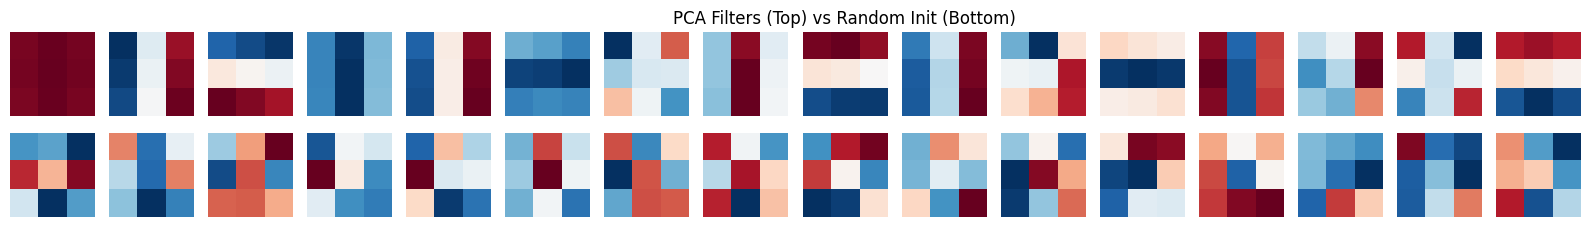


Observation: PCA filters often capture edge detectors and gradient patterns,
while random filters are unstructured noise.


In [ ]:
# Visualize PCA filters vs random filters (provided)
fig, axes = plt.subplots(2, 16, figsize=(16, 2.5))

# Row 1: PCA filters (first 16)
for i, ax in enumerate(axes[0]):
    filt = pca_filters[i, 0].cpu().numpy()
    vmax = np.abs(filt).max()
    ax.imshow(filt, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.axis('off')
    if i == 0:
        ax.set_ylabel('PCA', fontsize=10)

# Row 2: Random filters (from a fresh model)
random_model = CNN()
random_filters = random_model.conv1.weight.data
for i, ax in enumerate(axes[1]):
    filt = random_filters[i, 0].cpu().numpy()
    vmax = np.abs(filt).max()
    ax.imshow(filt, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.axis('off')
    if i == 0:
        ax.set_ylabel('Random', fontsize=10)

axes[0, 8].set_title('PCA Filters (Top) vs Random Init (Bottom)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nObservation: PCA filters often capture edge detectors and gradient patterns,")
print("while random filters are unstructured noise.")

In [ ]:
def create_pca_initialized_model(pca_filters, num_classes=10):
    """
    Create a CNN with the first conv layer initialized using PCA filters.

    Args:
        pca_filters: Tensor of shape (32, 1, 3, 3)
        num_classes: Number of output classes

    Returns:
        model: CNN with PCA-initialized conv1
    """
    model = CNN(num_classes=num_classes)

    # TODO: Initialize conv1 with PCA filters
    # Use torch.no_grad() context and model.conv1.weight.copy_()
    # Also zero out the bias: model.conv1.bias.zero_()
    with torch.no_grad():
        model.conv1.weight.copy_(pca_filters)
        model.conv1.bias.zero_()

    return model

In [ ]:
# Train PCA-initialized model
print("="*60)
print("Training PCA-Initialized CNN")
print("="*60)

pca_model = create_pca_initialized_model(pca_filters, num_classes=NUM_CLASSES).to(device)
pca_start = time.time()
pca_history = train_model(
    pca_model, train_loader, test_loader,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE, device=device
)
pca_total_time = time.time() - pca_start

print(f"\nTotal training time: {pca_total_time:.1f}s")
print(f"Final Test Accuracy: {pca_history['test_acc'][-1]:.2f}%")

Training PCA-Initialized CNN
Epoch [1/10] Train Loss: 0.4369, Train Acc: 84.13% | Test Loss: 0.3285, Test Acc: 88.60% | Time: 8.6s
Epoch [2/10] Train Loss: 0.2673, Train Acc: 90.18% | Test Loss: 0.2842, Test Acc: 89.76% | Time: 8.7s
Epoch [3/10] Train Loss: 0.2258, Train Acc: 91.68% | Test Loss: 0.2539, Test Acc: 90.60% | Time: 8.6s
Epoch [4/10] Train Loss: 0.1968, Train Acc: 92.69% | Test Loss: 0.2348, Test Acc: 91.38% | Time: 8.7s
Epoch [5/10] Train Loss: 0.1726, Train Acc: 93.65% | Test Loss: 0.2387, Test Acc: 91.14% | Time: 8.6s
Epoch [6/10] Train Loss: 0.1505, Train Acc: 94.34% | Test Loss: 0.2433, Test Acc: 91.52% | Time: 8.5s
Epoch [7/10] Train Loss: 0.1325, Train Acc: 94.97% | Test Loss: 0.2340, Test Acc: 91.73% | Time: 8.7s
Epoch [8/10] Train Loss: 0.1151, Train Acc: 95.69% | Test Loss: 0.2425, Test Acc: 92.00% | Time: 8.6s
Epoch [9/10] Train Loss: 0.1009, Train Acc: 96.18% | Test Loss: 0.2754, Test Acc: 91.81% | Time: 8.6s
Epoch [10/10] Train Loss: 0.0870, Train Acc: 96.72% |

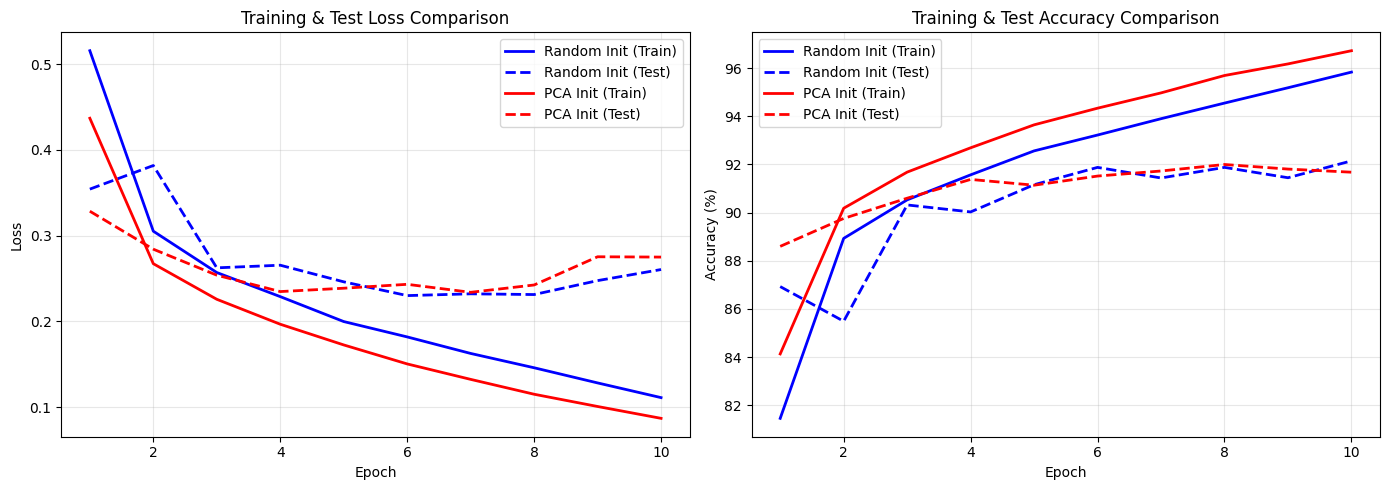


INITIALIZATION COMPARISON SUMMARY
Metric                         Random Init     PCA Init       
------------------------------------------------------------
Final Test Accuracy (%)        92.15           91.68          
Epoch 1 Test Accuracy (%)      86.93           88.60          
Total Training Time (s)        85.2            86.4           


In [ ]:
# Compare training curves: Random Init vs PCA Init (provided)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, NUM_EPOCHS + 1)

# Loss comparison
axes[0].plot(epochs, baseline_history['train_loss'], 'b-', label='Random Init (Train)', linewidth=2)
axes[0].plot(epochs, baseline_history['test_loss'], 'b--', label='Random Init (Test)', linewidth=2)
axes[0].plot(epochs, pca_history['train_loss'], 'r-', label='PCA Init (Train)', linewidth=2)
axes[0].plot(epochs, pca_history['test_loss'], 'r--', label='PCA Init (Test)', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Test Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy comparison
axes[1].plot(epochs, baseline_history['train_acc'], 'b-', label='Random Init (Train)', linewidth=2)
axes[1].plot(epochs, baseline_history['test_acc'], 'b--', label='Random Init (Test)', linewidth=2)
axes[1].plot(epochs, pca_history['train_acc'], 'r-', label='PCA Init (Train)', linewidth=2)
axes[1].plot(epochs, pca_history['test_acc'], 'r--', label='PCA Init (Test)', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training & Test Accuracy Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "="*60)
print("INITIALIZATION COMPARISON SUMMARY")
print("="*60)
print(f"{'Metric':<30} {'Random Init':<15} {'PCA Init':<15}")
print("-"*60)
print(f"{'Final Test Accuracy (%)':<30} {baseline_history['test_acc'][-1]:<15.2f} {pca_history['test_acc'][-1]:<15.2f}")
print(f"{'Epoch 1 Test Accuracy (%)':<30} {baseline_history['test_acc'][0]:<15.2f} {pca_history['test_acc'][0]:<15.2f}")
print(f"{'Total Training Time (s)':<30} {baseline_total_time:<15.1f} {pca_total_time:<15.1f}")

### 📝 Analysis Question 6.1 

Based on the PCA initialization experiment:

1. Does PCA initialization help in the **early epochs**? By how much?
2. Does PCA initialization improve **final accuracy**? Why or why not?
3. When would PCA initialization be most valuable in practice?



PCA initialization provides a clear advantage in the early epochs: after epoch 1, the PCA-initialized model achieves 88.60% test accuracy compared to86.93% for random initializatio,a 1.67% head start.This makes sense because PCA filters are pre-tuned to capture the principaldirections of image patch variance (edges,gradients), gving the networameaningful starting point rather than random noise. However,PCA initialization does not improve final accuracy, after 10 epochs, random initialization actually winslightly at 92.15% vs. 91.68%, because the Adamoptimizer is capable enough to find good filters from scrath regardless of startng point. PCA initializati would be most valuable in low-dataregimes where the network has fewer examples to learn good filters from, in scenarios with very limted compute budgets where fasterearly convergence matters, orwhen training with very low learning rates where escaping a poor initialization is slow.




## Part 7: Ablation Lab — PCA Component Budget 

The core ablation experiment: **How many PCA components are needed in the input before CNN performance saturates?**

We will:
1. Apply PCA to the flattened input images
2. Reconstruct images using k = {10, 50, 100, 200, 500, 784} components
3. Train a CNN on each reconstructed dataset
4. Analyze accuracy vs. retained variance

In [ ]:
def apply_pca_to_images(train_images, test_images, n_components):
    """
    Apply PCA dimensionality reduction to images.

    Args:
        train_images: Array of shape (N_train, 784) - flattened images
        test_images: Array of shape (N_test, 784) - flattened images
        n_components: Number of PCA components to keep

    Returns:
        train_reconstructed: Reconstructed training images (N_train, 784)
        test_reconstructed: Reconstructed test images (N_test, 784)
        explained_var: Total explained variance ratio
    """
    # TODO: Step 1 - Create PCA object with n_components
    # TODO: Step 2 - Fit on training data and transform both sets
    # TODO: Step 3 - Reconstruct images using inverse_transform
    # TODO: Step 4 - Get total explained variance
    # TODO: Step 1 - Create PCA object with n_components
    pca = PCA(n_components=n_components)

    pca.fit(train_images)
    train_transformed = pca.transform(train_images)
    test_transformed = pca.transform(test_images)

    train_reconstructed = pca.inverse_transform(train_transformed)
    test_reconstructed = pca.inverse_transform(test_transformed)
    explained_var = np.sum(pca.explained_variance_ratio_)

    return train_reconstructed, test_reconstructed, explained_var

In [ ]:
# Prepare flattened images for PCA (provided)
print("Preparing data for PCA ablation study...")

# Load raw (unnormalized) data for PCA
raw_train = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True)
raw_test = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True)

# Convert to numpy arrays and flatten
train_images_flat = raw_train.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
test_images_flat = raw_test.data.numpy().reshape(-1, 784).astype(np.float32) / 255.0
train_labels_np = raw_train.targets.numpy()
test_labels_np = raw_test.targets.numpy()

print(f"Training images shape: {train_images_flat.shape}")
print(f"Test images shape: {test_images_flat.shape}")

Preparing data for PCA ablation study...
Training images shape: (60000, 784)
Test images shape: (10000, 784)


In [ ]:
# Run ablation experiment (this will take ~15-20 minutes)
COMPONENT_BUDGETS = [10, 50, 100, 200, 500, 784]  # 784 = full dimensionality

ablation_results = []

for n_components in COMPONENT_BUDGETS:
    print(f"\n{'='*60}")
    print(f"Training with {n_components} PCA components")
    print(f"{'='*60}")

    # Apply PCA (or skip for full dimensionality)
    if n_components < 784:
        train_recon, test_recon, explained_var = apply_pca_to_images(
            train_images_flat, test_images_flat, n_components
        )
        print(f"Explained variance: {explained_var*100:.2f}%")
    else:
        train_recon = train_images_flat
        test_recon = test_images_flat
        explained_var = 1.0
        print("Using full dimensionality (no PCA)")

    # Reshape to image format and normalize
    train_recon_tensor = torch.tensor(train_recon.reshape(-1, 1, 28, 28), dtype=torch.float32)
    test_recon_tensor = torch.tensor(test_recon.reshape(-1, 1, 28, 28), dtype=torch.float32)

    # Normalize using Fashion-MNIST statistics
    train_recon_tensor = (train_recon_tensor - 0.2860) / 0.3530
    test_recon_tensor = (test_recon_tensor - 0.2860) / 0.3530

    # Create data loaders
    train_labels_tensor = torch.tensor(train_labels_np, dtype=torch.long)
    test_labels_tensor = torch.tensor(test_labels_np, dtype=torch.long)

    pca_train_dataset = TensorDataset(train_recon_tensor, train_labels_tensor)
    pca_test_dataset = TensorDataset(test_recon_tensor, test_labels_tensor)

    pca_train_loader = DataLoader(pca_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    pca_test_loader = DataLoader(pca_test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Train model
    model = CNN(num_classes=NUM_CLASSES).to(device)
    start_time = time.time()
    history = train_model(
        model, pca_train_loader, pca_test_loader,
        num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE, device=device,
        verbose=False
    )
    training_time = time.time() - start_time

    final_acc = history['test_acc'][-1]
    print(f"Final Test Accuracy: {final_acc:.2f}%")
    print(f"Training Time: {training_time:.1f}s")

    ablation_results.append({
        'n_components': n_components,
        'explained_variance': explained_var,
        'test_accuracy': final_acc,
        'training_time': training_time,
        'history': history
    })


Training with 10 PCA components
Explained variance: 71.99%
Final Test Accuracy: 83.24%
Training Time: 25.2s

Training with 50 PCA components
Explained variance: 86.27%
Final Test Accuracy: 89.36%
Training Time: 25.2s

Training with 100 PCA components
Explained variance: 91.23%
Final Test Accuracy: 90.88%
Training Time: 25.2s

Training with 200 PCA components
Explained variance: 95.36%
Final Test Accuracy: 91.23%
Training Time: 25.2s

Training with 500 PCA components
Explained variance: 99.26%
Final Test Accuracy: 91.68%
Training Time: 25.2s

Training with 784 PCA components
Using full dimensionality (no PCA)
Final Test Accuracy: 92.00%
Training Time: 25.1s


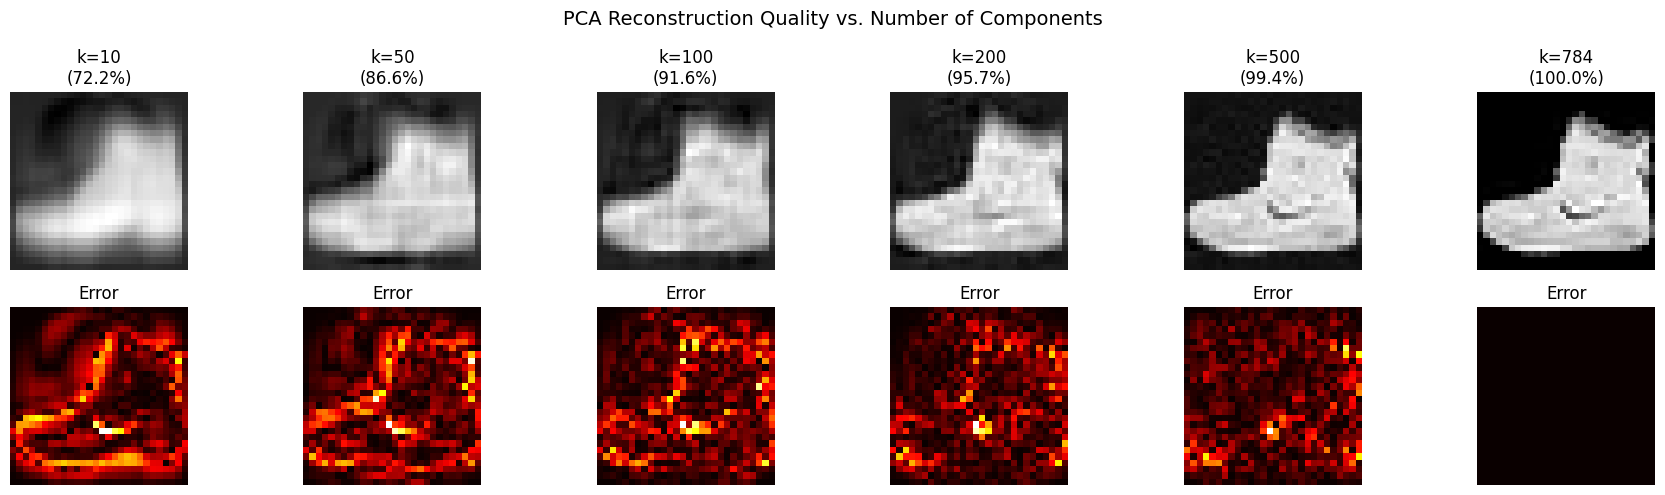

In [ ]:
# Visualize reconstructed images at different component levels (provided)
sample_idx = 0
sample_image = train_images_flat[sample_idx]

fig, axes = plt.subplots(2, len(COMPONENT_BUDGETS), figsize=(18, 5))

for i, n_components in enumerate(COMPONENT_BUDGETS):
    if n_components < 784:
        pca = PCA(n_components=n_components)
        pca.fit(train_images_flat[:5000])
        reduced = pca.transform(sample_image.reshape(1, -1))
        reconstructed = pca.inverse_transform(reduced).reshape(28, 28)
        var = pca.explained_variance_ratio_.sum()
    else:
        reconstructed = sample_image.reshape(28, 28)
        var = 1.0

    axes[0, i].imshow(reconstructed, cmap='gray')
    axes[0, i].set_title(f'k={n_components}\n({var*100:.1f}%)')
    axes[0, i].axis('off')

    # Show difference from original
    diff = np.abs(sample_image.reshape(28, 28) - reconstructed)
    axes[1, i].imshow(diff, cmap='hot')
    axes[1, i].set_title(f'Error')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Reconstruction', fontsize=10)
axes[1, 0].set_ylabel('Abs. Error', fontsize=10)
plt.suptitle('PCA Reconstruction Quality vs. Number of Components', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Ablation Results Summary (provided)
print("\n" + "="*70)
print("ABLATION STUDY RESULTS: PCA COMPONENT BUDGET")
print("="*70)
print(f"{'Components':<12} {'Var Explained':<16} {'Test Acc (%)':<14} {'Time (s)':<10}")
print("-"*70)

for result in ablation_results:
    print(f"{result['n_components']:<12} {result['explained_variance']*100:<16.2f} "
          f"{result['test_accuracy']:<14.2f} {result['training_time']:<10.1f}")


ABLATION STUDY RESULTS: PCA COMPONENT BUDGET
Components   Var Explained    Test Acc (%)   Time (s)  
----------------------------------------------------------------------
10           71.99            83.24          25.2      
50           86.27            89.36          25.2      
100          91.23            90.88          25.2      
200          95.36            91.23          25.2      
500          99.26            91.68          25.2      
784          100.00           92.00          25.1      


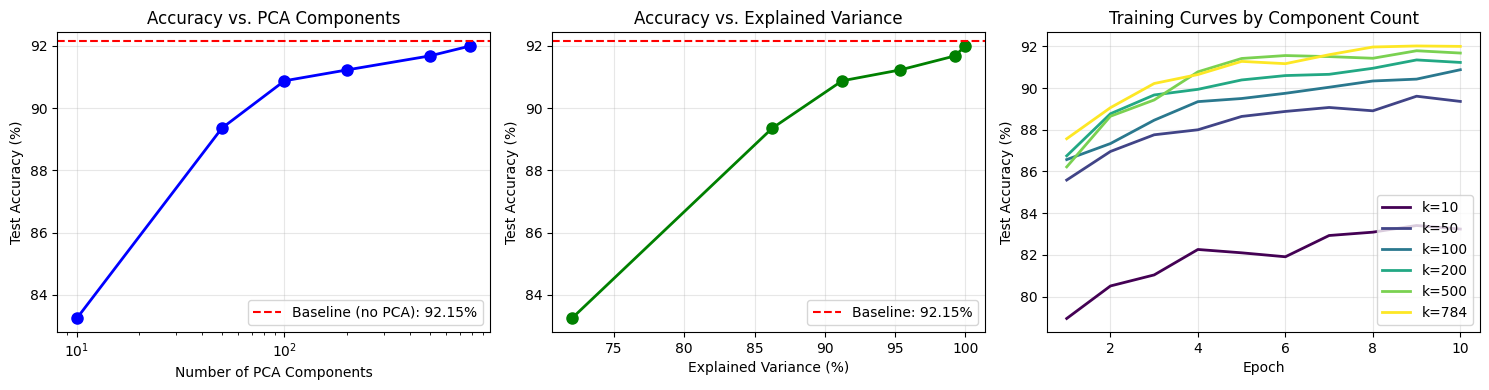

In [ ]:
# Visualization: Ablation Results (provided)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

components = [r['n_components'] for r in ablation_results]
accuracies = [r['test_accuracy'] for r in ablation_results]
variances = [r['explained_variance'] * 100 for r in ablation_results]
times = [r['training_time'] for r in ablation_results]

# Plot 1: Accuracy vs Components
axes[0].plot(components, accuracies, 'bo-', linewidth=2, markersize=8)
axes[0].axhline(y=baseline_history['test_acc'][-1], color='r', linestyle='--',
                label=f'Baseline (no PCA): {baseline_history["test_acc"][-1]:.2f}%')
axes[0].set_xlabel('Number of PCA Components')
axes[0].set_ylabel('Test Accuracy (%)')
axes[0].set_title('Accuracy vs. PCA Components')
axes[0].set_xscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Accuracy vs Explained Variance
axes[1].plot(variances, accuracies, 'go-', linewidth=2, markersize=8)
axes[1].axhline(y=baseline_history['test_acc'][-1], color='r', linestyle='--',
                label=f'Baseline: {baseline_history["test_acc"][-1]:.2f}%')
axes[1].set_xlabel('Explained Variance (%)')
axes[1].set_ylabel('Test Accuracy (%)')
axes[1].set_title('Accuracy vs. Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Training curves comparison
colors = plt.cm.viridis(np.linspace(0, 1, len(ablation_results)))
for result, color in zip(ablation_results, colors):
    axes[2].plot(range(1, NUM_EPOCHS+1), result['history']['test_acc'],
                 color=color, label=f"k={result['n_components']}", linewidth=2)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Test Accuracy (%)')
axes[2].set_title('Training Curves by Component Count')
axes[2].legend(loc='lower right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Find the "knee" - diminishing returns analysis (provided)
accuracy_gains = np.diff(accuracies)
component_increases = np.diff(components)
efficiency = accuracy_gains / component_increases

print("\n" + "="*60)
print("DIMINISHING RETURNS ANALYSIS")
print("="*60)
print(f"{'Transition':<20} {'Acc Gain (%)':<15} {'Components Added':<18} {'Efficiency':<12}")
print("-"*60)

for i in range(len(accuracy_gains)):
    transition = f"{components[i]} → {components[i+1]}"
    print(f"{transition:<20} {accuracy_gains[i]:<15.2f} {component_increases[i]:<18} {efficiency[i]:<12.4f}")

# Find optimal point (highest efficiency)
optimal_idx = np.argmax(efficiency)
print(f"\n🎯 Recommended: Use {components[optimal_idx+1]} components")
print(f"   Achieves {accuracies[optimal_idx+1]:.2f}% accuracy with {variances[optimal_idx+1]:.1f}% variance retained")


DIMINISHING RETURNS ANALYSIS
Transition           Acc Gain (%)    Components Added   Efficiency  
------------------------------------------------------------
10 → 50              6.12            40                 0.1530      
50 → 100             1.52            50                 0.0304      
100 → 200            0.35            100                0.0035      
200 → 500            0.45            300                0.0015      
500 → 784            0.32            284                0.0011      

🎯 Recommended: Use 50 components
   Achieves 89.36% accuracy with 86.3% variance retained


### 📝 Analysis Question 7.1 

Based on the ablation study:

1. What is the "sweet spot" for the number of PCA components (best accuracy vs. efficiency trade-off)?
2. How much accuracy is lost when using only 10 components vs. 100 components?
3. Why do you think CNNs are relatively robust to aggressive dimensionality reduction in the input?



The sweet spot is 50 components, which achieves 89.36% accuracy while retaining only 86.3% of input varianc,thediminishing returns analysis confirms this transition (10->50) has by far the highest efficincy at 0.153% accuracygain per component, compared to 0.030 for 50->100 and below 0.004 for all subsequent transitions. Using only 10 components loses 8.88 percentage points relative to 100 components (83.24% vs90.88%), which is a significant drop reflecting that 10 components at 72% variance discard too much strucural information, class-distinguishing details like texture and fne shape boundaries are lost. Using 100 components recovers most of that, achieving 90.88% with 91.2% variance retained, only 1.12 points beowthe full-dimensionality baseline. CNNs are robust to aggressive dimensionlity reduction because the convolutional layers themselves act as learned feature extractors — they can recover local structure, edges,and spatial patterns from a smoothed reconstruction far more effectivly than a global classifier could. pCA reconstruction preserves the dominant low-frequency structure of each image(overall shape, contrast regions) while discarding high-frequency noise, and these dominant structures carry most of the class-relevant information for Fashion-MNIST categories like trousers, bags,and shoes.




## Part 8: Critical Analysis & Discussion 

In [ ]:
# Final Summary Table (provided)
print("\n" + "="*70)
print("COMPLETE EXPERIMENT SUMMARY")
print("="*70)

print("\n📊 BASELINE vs PCA INITIALIZATION:")
print(f"  Random Init Final Accuracy: {baseline_history['test_acc'][-1]:.2f}%")
print(f"  PCA Init Final Accuracy:    {pca_history['test_acc'][-1]:.2f}%")
print(f"  Epoch 1 Advantage (PCA):    {pca_history['test_acc'][0] - baseline_history['test_acc'][0]:.2f}%")

print("\n📉 INTRINSIC DIMENSIONALITY (Components for 95% variance):")
for layer, dim in intrinsic_dims.items():
    print(f"  {layer}: {dim} components")

print("\n🔬 ABLATION: PCA COMPONENT BUDGET:")
print(f"  Best accuracy achieved: {max(accuracies):.2f}% at k={components[np.argmax(accuracies)]}")
print(f"  Accuracy with k=100:    {ablation_results[2]['test_accuracy']:.2f}% ({ablation_results[2]['explained_variance']*100:.1f}% variance)")
print(f"  Accuracy drop at k=10:  {ablation_results[0]['test_accuracy']:.2f}% ({ablation_results[0]['explained_variance']*100:.1f}% variance)")


COMPLETE EXPERIMENT SUMMARY

📊 BASELINE vs PCA INITIALIZATION:
  Random Init Final Accuracy: 92.15%
  PCA Init Final Accuracy:    91.68%
  Epoch 1 Advantage (PCA):    1.67%

📉 INTRINSIC DIMENSIONALITY (Components for 95% variance):
  conv1: 2 components
  conv2: 4 components
  conv3: 5 components
  fc1: 43 components

🔬 ABLATION: PCA COMPONENT BUDGET:
  Best accuracy achieved: 92.00% at k=784
  Accuracy with k=100:    90.88% (91.2% variance)
  Accuracy drop at k=10:  83.24% (72.0% variance)


### 📝 Critical Discussion Questions

Answer the following questions in the markdown cell below. Each question is worth 5 points.

---

**Question 8.1:** When does PCA preprocessing **help** CNN performance, and when does it **hurt**? Provide specific evidence from your experiments.

---

**Question 8.2:** What do the latent space PCA visualizations reveal about how CNNs process information layer by layer? How does this relate to the concept of "neural collapse"?

---

**Question 8.3:** Based on all your experiments, discuss whether classical methods (PCA) and deep learning (CNNs) are **competing** or **complementary** approaches. Provide at least two specific examples from your results to support your argument.

### Your Answers for Part 8:
**Answer 8.1:**
PCA preprocessing helps CNN performance when the number ofcomponentis large enough to retainthe class-discriminativestructurof the input, at100 components(91.2% variance),the accracy gapversus fulldimensionality input is only 1.12 points, meaning the CNNperforms nearly as well on compressed data. It also helps at the filter initialization level in early training,were PCA-derived filters gave a 1.67% accuracy advantage in epoch 1 by starting from structured, variance-capturing features rather than randomnoise. However, PCA preprocessing hurts performancewhen the component budget is too aggressive: at 10 components, accuracy drops to 83.24%,nearly 9 points below the100-component modelbecause the reconstructed images lose fine-grained texture and boundary information that CNNs rely on to discriminate similar classes like shirts, pullovers, and coats. PCA also hurts finalaccuracy when used for filter initialization: despite the early-epoch advantage, the PCA-initialized model finished at 91.68% versus the random-init baseline of 92.15%, suggesting that locking the first layer into PCA-derived features slightly constrains what the network ultimately learns compared to fully data-driven optimization.



**Answer 8.2:**
The latent spacePCA visualizations reveal a clear progressive structuringof repres]entations layer by layer. In conv1,only 2 components capture95% of the variance and the2D scatter shows heavily overlapping class clusters,the network is still operating in a low-level feature space where a t-shirt and a shirt look nearly identical. By conv3, 5 components ae needed and some class structure begins to emerge. At fc1, 43components are required, and the scatter plot shows meaningfullyseparated class clusters, indicating the network has built high-imensional, discriminative representations. This relates directly to the concept of neural collapse,,ma phenomenon observed in the final layers of well-trained classifiers where within-class representations collapse to a single point and between-class representations form a maximally spread, symmetricgeometry. The fc1 layer in your results shows early signs of this: classes with visually distinct appearances (trouser bagandal)form tight, well-separated clusters,while visually similar classesshirt, pullover, coat) remain partially overlapping, consistent with neural collapse being incomplete after only 10 epochs of training.



**Answer 8.3:**
The experiments strongly suggest PCA and CNNs are complementary rather than competing approaches. First, the PCA filter initialization experiment shows that unsupervised PCA eigenvectors,computed with no knowledge ofclass labelsalready capture featuresedges, gradients) that are ueful for supervised classification, giving a 1.67% accuracy head start in epoch 1. This means PCA can meaningfuly inform CNNweight initialization, acting as a prior that aligns with what the network would eventually learn anyway. Second, the ablation study demonstrates that PCA compression can dramaticaly reduce input dimensionality from 784 to 50 dimensions with only a2.79% accuracy drop(92.00% to 89.36%),showing PCA can serve as an efficient preprocessing step that reduces data complexity withoutdestroying CNN-relevant structure. Rather than replacing CNNs, PCA provides a principled,comptationally cheap way to preprocss, initialize, or analyze the and the latent space PCA analysis itself is only possible because theCNN first learns rich representations that PCA can then interpret. The two methods operate on different axesPCA maximizes explained variance in an unspervised, linear, interpretable way, while CNNs maximize classification accuracythrough nonlinear, spervised, hierarchical feature learning. Used together, they are stronger than either alone.

